# Text Preprocessing

1. Read the _childrens_books.csv_ file into a Jupyter Notebook
2. Within the Description column:
* Make all the text lowercase
* Remove all \xa0 characters
* Remove all punctuation

In [145]:
import pandas as pd
import os
pd.set_option('display.max_colwidth', None)  # Display full text in DataFrame cells

In [146]:
data = pd.read_csv('childrens_books.csv')
data.head()

,Ranking,Title,Author,Year,Rating,Description
0,1,Where the Wild Things Are,Maurice Sendak,1963,4.25,"Where the Wild Things Are follows Max, a young boy who, after being sent to his room for misbehaving, imagines sailing to an island filled with wild creatures. As their king, Max tames the beasts and eventually returns home to find his supper waiting for him. This iconic book explores themes of imagination, adventure, and the complex emotions of childhood, all captured through Sendak's whimsical illustrations and story."
1,2,The Very Hungry Caterpillar,Eric Carle,1969,4.34,"The Very Hungry Caterpillar tells the story of a caterpillar who eats through a variety of foods before eventually becoming a butterfly. Eric Carle’s use of colorful collage illustrations and rhythmic text has made this book a beloved classic for young readers. The simple, engaging story introduces children to days of the week, counting, and the concept of metamorphosis. It’s a staple in early childhood education."
2,3,The Giving Tree,Shel Silverstein,1964,4.38,"The Giving Tree is a touching and bittersweet story about a tree that gives everything it has to a boy over the course of his life. As the boy grows up, he takes more from the tree, and the tree continues to give, even when it has little left. Silverstein’s minimalist text and illustrations convey deep themes of unconditional love, selflessness, and the passage of time. It has sparked much discussion about relationships and sacrifice."
3,4,Green Eggs and Ham,Dr. Seuss,1960,4.31,"In Green Eggs and Ham, Sam-I-Am tries to convince a reluctant character to try a dish of green eggs and ham, despite his resistance. Through repetition and rhyme, Dr. Seuss’s classic story about being open to new experiences encourages children to be adventurous and try things outside their comfort zone. The playful illustrations and humorous dialogue make it a fun and educational read for young readers."
4,5,Goodnight Moon,Margaret Wise Brown,1947,4.31,"Goodnight Moon is a gentle, rhythmic bedtime story where a little bunny says goodnight to everything in his room, from the moon to the ""quiet old lady whispering hush."" Its repetitive structure and comforting tone make it ideal for young children. The simple illustrations by Clement Hurd complement the soothing nature of the story, making it a beloved classic for sleep-time reading."


In [147]:
data.Description.iloc[0]

"Where the Wild Things Are\xa0follows Max, a young boy who, after being sent to his room for misbehaving, imagines sailing to an island filled with wild creatures. As their king, Max tames the beasts and eventually returns home to find his supper waiting for him. This iconic book explores themes of imagination, adventure, and the complex emotions of childhood, all captured through Sendak's whimsical illustrations and story."

In [148]:
# funtion to clean the description column of the dataframe
def lower_replace_special_char(series):
    """
    This function takes a pandas Series as input and performs the following operations:
    1. Converts all text to lowercase.
    2. Replaces special characters with spaces.
    
    Parameters:
    series (pd.Series): The input pandas Series containing text data.
    
    Returns:
    pd.Series: A new pandas Series with cleaned text data.
    """
    # Convert to lowercase    
    output = series.str.lower()
    # Replace square brackets with empty string and remove special characters
    output = output.str.replace(r'\[.*?\]', '', regex=True)
    output = output.str.replace(r'[^\w\s]', '', regex=True)
    # Replace non-breaking spaces with regular spaces
    output = output.str.replace(r'\xa0', ' ', regex=True)
    return output

In [149]:
df = data

In [150]:
df['Description_clean'] = lower_replace_special_char(df.Description)

In [151]:
df.Description_clean.iloc[0]

'where the wild things are follows max a young boy who after being sent to his room for misbehaving imagines sailing to an island filled with wild creatures as their king max tames the beasts and eventually returns home to find his supper waiting for him this iconic book explores themes of imagination adventure and the complex emotions of childhood all captured through sendaks whimsical illustrations and story'

In [152]:
df.Description_clean.iloc[0]

'where the wild things are follows max a young boy who after being sent to his room for misbehaving imagines sailing to an island filled with wild creatures as their king max tames the beasts and eventually returns home to find his supper waiting for him this iconic book explores themes of imagination adventure and the complex emotions of childhood all captured through sendaks whimsical illustrations and story'

## 2. Text Preprocessing with spaCy

In addition to the lowercasing and special character removal from the previous assignment, within the cleaned Description column:
* Tokenize the text
* Lemmatize the text
* Remove stop words

In [153]:
import spacy
nlp = spacy.load("en_core_web_sm")

In [154]:
df.head(2)

,Ranking,Title,Author,Year,Rating,Description,Description_clean
0,1,Where the Wild Things Are,Maurice Sendak,1963,4.25,"Where the Wild Things Are follows Max, a young boy who, after being sent to his room for misbehaving, imagines sailing to an island filled with wild creatures. As their king, Max tames the beasts and eventually returns home to find his supper waiting for him. This iconic book explores themes of imagination, adventure, and the complex emotions of childhood, all captured through Sendak's whimsical illustrations and story.",where the wild things are follows max a young boy who after being sent to his room for misbehaving imagines sailing to an island filled with wild creatures as their king max tames the beasts and eventually returns home to find his supper waiting for him this iconic book explores themes of imagination adventure and the complex emotions of childhood all captured through sendaks whimsical illustrations and story
1,2,The Very Hungry Caterpillar,Eric Carle,1969,4.34,"The Very Hungry Caterpillar tells the story of a caterpillar who eats through a variety of foods before eventually becoming a butterfly. Eric Carle’s use of colorful collage illustrations and rhythmic text has made this book a beloved classic for young readers. The simple, engaging story introduces children to days of the week, counting, and the concept of metamorphosis. It’s a staple in early childhood education.",the very hungry caterpillar tells the story of a caterpillar who eats through a variety of foods before eventually becoming a butterfly eric carles use of colorful collage illustrations and rhythmic text has made this book a beloved classic for young readers the simple engaging story introduces children to days of the week counting and the concept of metamorphosis its a staple in early childhood education


In [155]:
phrase = df.Description_clean.iloc[0]
phrase

'where the wild things are follows max a young boy who after being sent to his room for misbehaving imagines sailing to an island filled with wild creatures as their king max tames the beasts and eventually returns home to find his supper waiting for him this iconic book explores themes of imagination adventure and the complex emotions of childhood all captured through sendaks whimsical illustrations and story'

In [156]:
doc1 = nlp(phrase)
doc1

where the wild things are follows max a young boy who after being sent to his room for misbehaving imagines sailing to an island filled with wild creatures as their king max tames the beasts and eventually returns home to find his supper waiting for him this iconic book explores themes of imagination adventure and the complex emotions of childhood all captured through sendaks whimsical illustrations and story

In [157]:
# lammetize, and filter out stop words
norm = [token.lemma_ for token in doc1 if not token.is_stop]
" ".join(norm)

'wild thing follow max young boy send room misbehave imago sail island fill wild creature king max tame beast eventually return home find supper wait iconic book explore theme imagination adventure complex emotion childhood capture sendak whimsical illustration story'

In [160]:
#part of speech tagging, and filter out stop words
norm1 =[token.text for token in doc1 if token.pos_ in ['NOUN', 'VERB', 'ADJ']]
" ".join(norm1)

'wild things follows young boy sent room misbehaving imagines sailing island filled wild creatures king tames beasts returns find supper waiting iconic book explores themes imagination adventure complex emotions childhood captured sendaks whimsical illustrations story'

## NLP Pipeline

In [161]:
# funtion to clean the description column of the dataframe
def lower_replace_special_char(series):
    # Convert to lowercase    
    output = series.str.lower()
    # Replace square brackets with empty string and remove special characters
    output = output.str.replace(r'\[.*?\]', '', regex=True)
    output = output.str.replace(r'[^\w\s]', '', regex=True)
    # Replace non-breaking spaces with regular spaces
    output = output.str.replace(r'\xa0', ' ', regex=True)
    return output

def lemma_token_stopword(text):
    doc = nlp(text)
    output = [token.lemma_ for token in doc if not token.is_stop]
    output = " ".join(output)
    return output

def filter_pos(text, pos_tags=['NOUN', 'PROPN']):
    doc = nlp(text)
    output =[token.text for token in doc if token.pos_ in pos_tags]
    output = " ".join(output)
    return output

#pipeline or abstract function to clean the description column of the dataframe
def nlp_pipeline(series):
    output = lower_replace_special_char(series)
    output = output.apply(lemma_token_stopword)
    output = output.apply(filter_pos, pos_tags=['NOUN', 'PROPN', 'VERB','PRON'])
    return output

In [162]:
df.Description_clean

0                            where the wild things are follows max a young boy who after being sent to his room for misbehaving imagines sailing to an island filled with wild creatures as their king max tames the beasts and eventually returns home to find his supper waiting for him this iconic book explores themes of imagination adventure and the complex emotions of childhood all captured through sendaks whimsical illustrations and story
1                                the very hungry caterpillar tells the story of a caterpillar who eats through a variety of foods before eventually becoming a butterfly eric carles use of colorful collage illustrations and rhythmic text has made this book a beloved classic for young readers the simple engaging story introduces children to days of the week counting and the concept of metamorphosis its a staple in early childhood education
2            the giving tree is a touching and bittersweet story about a tree that gives everything it has to a boy 

In [163]:
df['Description_clean'] = nlp_pipeline(df.Description_clean)

In [164]:
df.head(2)

,Ranking,Title,Author,Year,Rating,Description,Description_clean
0,1,Where the Wild Things Are,Maurice Sendak,1963,4.25,"Where the Wild Things Are follows Max, a young boy who, after being sent to his room for misbehaving, imagines sailing to an island filled with wild creatures. As their king, Max tames the beasts and eventually returns home to find his supper waiting for him. This iconic book explores themes of imagination, adventure, and the complex emotions of childhood, all captured through Sendak's whimsical illustrations and story.",thing follow max boy send room misbehave imago sail island fill creature king max tame beast return home find supper wait book explore theme imagination adventure emotion childhood capture sendak illustration story
1,2,The Very Hungry Caterpillar,Eric Carle,1969,4.34,"The Very Hungry Caterpillar tells the story of a caterpillar who eats through a variety of foods before eventually becoming a butterfly. Eric Carle’s use of colorful collage illustrations and rhythmic text has made this book a beloved classic for young readers. The simple, engaging story introduces children to days of the week, counting, and the concept of metamorphosis. It’s a staple in early childhood education.",caterpillar tell story caterpillar eat variety food butterfly eric carles use collage illustration text book reader story introduce child day week counting concept metamorphosis staple childhood education


## CountVectorizer assignment

1. Vectorize the cleaned and normalized text using Count Vectorizer with the default parameters
2. Modify the Count Vectorizer parameters to reduce the number of columns:
* Remove stop words
* Set a minimum document frequency of 10%
3. Use the updated Count Vectorizer to identify the:
* Top 10 most common terms
* Top 10 least common terms that appear in at least 10% of the documents
4. Create a horizontal bar chart of the top 10 most common terms

In [165]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()
dtm = cv.fit_transform(df.Description_clean)
dtm_df = pd.DataFrame(dtm.toarray(), columns=cv.get_feature_names_out())
dtm_df

,aa,aaron,ability,absurd,absurdity,acceptance,accompany,accuracy,acre,action,...,world,worldbuilde,wrap,wrinkle,write,writing,year,young,zany,zone
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
96,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
97,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,1,0,0,0
98,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,0


In [166]:
cv2 = CountVectorizer(stop_words='english',ngram_range=(1,2), min_df=0.10)
dtm2 = cv2.fit_transform(df.Description_clean)
dtm_df2 = pd.DataFrame(dtm2.toarray(), columns=cv2.get_feature_names_out())
dtm_df2

,adventure,book,boy,character,child,courage,embark,engage,explore,explore theme,...,rhyme,series,story,teach,tell,tell story,text,theme,way,world
0,1,1,1,0,0,0,0,0,1,1,...,0,0,1,0,0,0,0,1,0,0
1,0,1,0,0,1,0,0,0,0,0,...,0,0,2,0,1,1,1,0,0,0
2,0,0,2,0,0,0,0,0,0,0,...,0,0,1,0,0,0,1,1,0,0
3,0,0,0,1,1,0,0,0,0,0,...,1,0,1,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,...,0,0,2,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0,0,0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,0,0
96,0,1,0,0,1,0,0,0,1,0,...,0,0,0,0,0,0,0,0,0,0
97,0,1,0,0,0,0,0,0,1,1,...,0,1,0,0,0,0,0,1,0,1
98,1,1,0,0,0,1,0,0,1,0,...,0,1,0,0,0,0,0,1,0,0


In [167]:
top_10_dtm_freq = dtm_df2.sum().sort_values(ascending=False).head(10)
top_10_dtm_freq

story           106
book             75
child            66
illustration     54
reader           54
adventure        39
theme            33
explore          30
follow           29
series           28
dtype: int64

<Axes: title={'center': 'Top 10 Most Frequent Terms'}, xlabel='Frequency', ylabel='Terms'>

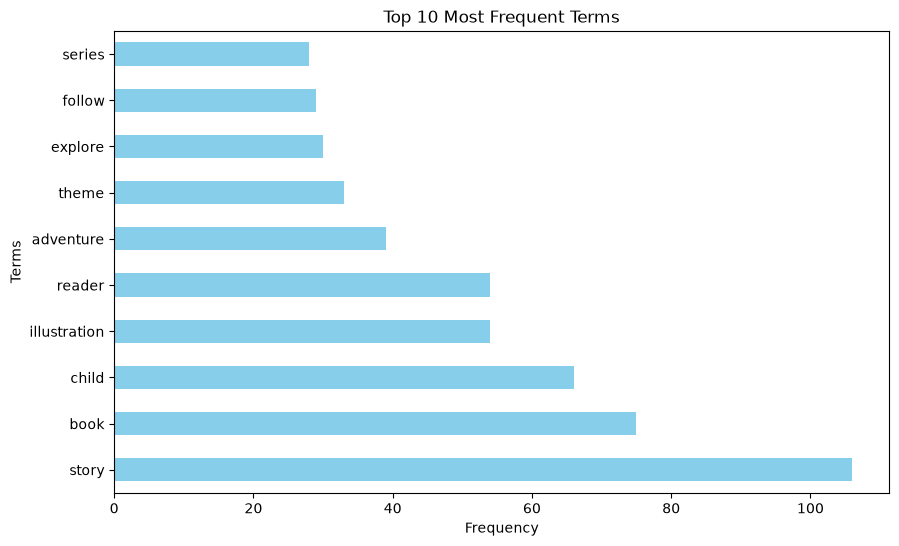

In [ ]:
# Top 10
top_10_dtm_freq.plot(kind='barh', title='Top 10 Most Frequent Terms',xlabel='Frequency', ylabel='Terms', color='skyblue', figsize=(10,6))

In [ ]:
# Buttom top 10
least_top_10_dtm_freq = dtm_df2.sum().sort_values(ascending=True).head(10)
least_top_10_dtm_freq

embark         10
joy            10
fun            11
girl           11
imagination    11
importance     11
message        12
courage        12
rhyme          12
text           12
dtype: int64

<Axes: title={'center': 'Least 10 Most Frequent Terms'}, xlabel='Frequency', ylabel='Terms'>

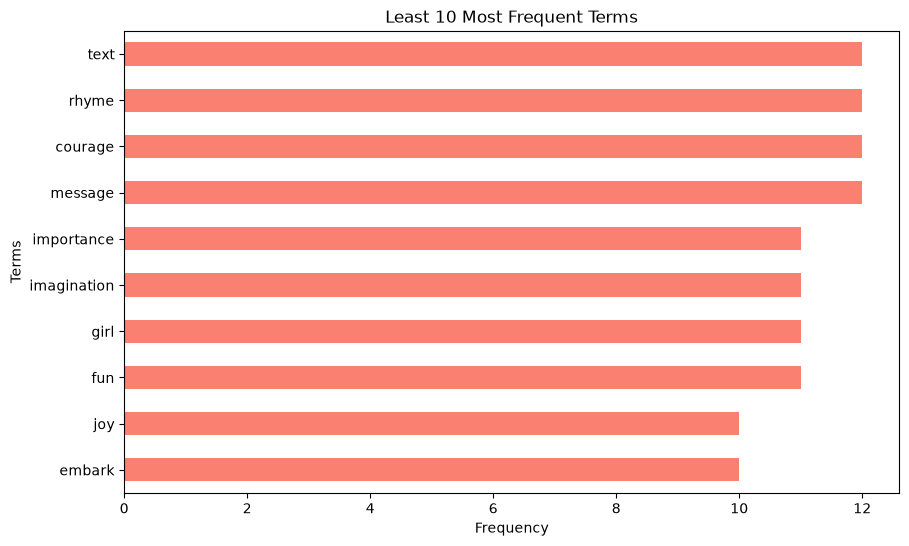

In [170]:
least_top_10_dtm_freq.plot(kind='barh', title='Least 10 Most Frequent Terms',xlabel='Frequency', ylabel='Terms', color='salmon', figsize=(10,6))

# TF-IDF Vectorizer

1. Vectorize the cleaned and normalized text using TF-IDF Vectorizer with the default parameters
2. Modify the TF-IDF Vectorizer parameters to reduce the number of columns:
* Remove stop words
* Set a minimum document frequency of 10%
* Set a maximum document frequency of 50%
3. Using the updated TF-IDF Vectorizer, create a  horizontal bar chart of the top 10 most highly weighted terms
4. Compare the Count Vectorizer bar chart from the previous assignment with the TF-IDF Vectorizer bar chart and note the differences in the top term lists

In [171]:
from sklearn.feature_extraction.text import TfidfVectorizer

tv = TfidfVectorizer()
tfidf = tv.fit_transform(df.Description_clean)
tfidf_df = pd.DataFrame(tfidf.toarray(), columns=tv.get_feature_names_out())
tfidf_df

,aa,aaron,ability,absurd,absurdity,acceptance,accompany,accuracy,acre,action,...,world,worldbuilde,wrap,wrinkle,write,writing,year,young,zany,zone
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.191538
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
96,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.000000,0.0,0.0,0.000000
97,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.093244,0.0,0.0,0.0,0.0,0.0,0.135638,0.0,0.0,0.000000
98,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.0,0.0,0.0,0.0,0.0,0.147542,0.0,0.0,0.000000


In [178]:
tv2 = TfidfVectorizer(stop_words="english", min_df=.1, max_df=.5)
tfidf2 = tv2.fit_transform(df.Description_clean)
tfidf_df2 = pd.DataFrame(tfidf2.toarray(), columns=tv2.get_feature_names_out())
tfidf_df2

,adventure,boy,character,courage,embark,engage,explore,family,follow,friendship,...,read,reader,rhyme,series,teach,tell,text,theme,way,world
0,0.340107,0.484584,0.000000,0.000000,0.0,0.0,0.355148,0.0,0.360487,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.344968,0.0,0.00000
1,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.342941,0.000000,0.000000,0.00000,0.443579,0.592659,0.000000,0.0,0.00000
2,0.000000,0.731980,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.375104,0.260543,0.0,0.00000
3,0.000000,0.000000,0.460062,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,...,0.425116,0.291885,0.504427,0.000000,0.00000,0.000000,0.000000,0.000000,0.0,0.00000
4,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.0,0.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.0,0.00000
96,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.465346,0.0,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.0,0.00000
97,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.399655,0.0,0.000000,0.454349,...,0.000000,0.000000,0.000000,0.446550,0.00000,0.000000,0.000000,0.388199,0.0,0.53267
98,0.350595,0.000000,0.000000,0.525401,0.0,0.0,0.366100,0.0,0.000000,0.416201,...,0.000000,0.000000,0.000000,0.409058,0.00000,0.000000,0.000000,0.355606,0.0,0.00000


In [191]:
top10 = tfidf_df2.sum().sort_values().tail(10)
top10

friendship     7.764453
lesson         7.928640
make           8.641934
follow         9.193416
tell           9.201470
series         9.332142
explore        9.459039
theme          9.558861
adventure     10.929743
reader        14.268757
dtype: float64

<Axes: title={'center': 'Top 10 Most Frequent Terms'}, xlabel='Frequency', ylabel='Terms'>

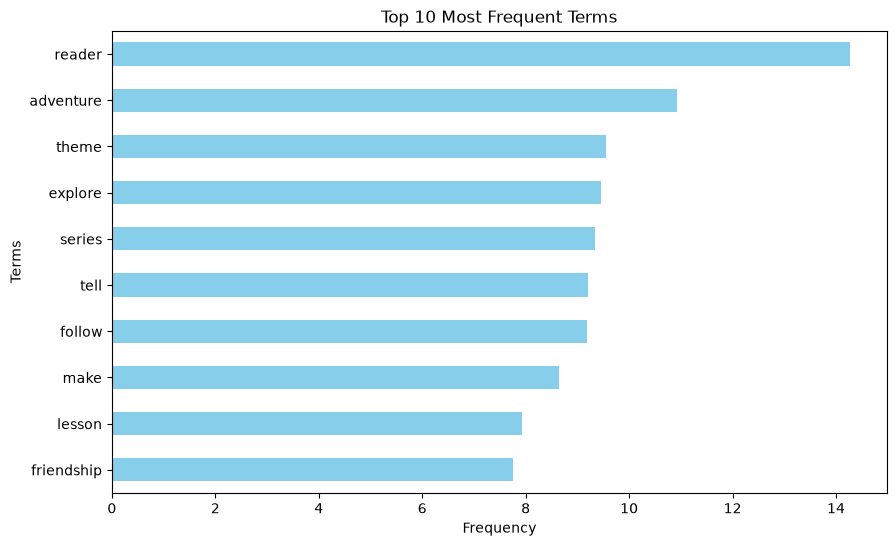

In [195]:
top10.plot(kind='barh', title='Top 10 Most Frequent Terms',xlabel='Frequency', ylabel='Terms', color='skyblue', figsize=(10,6) )

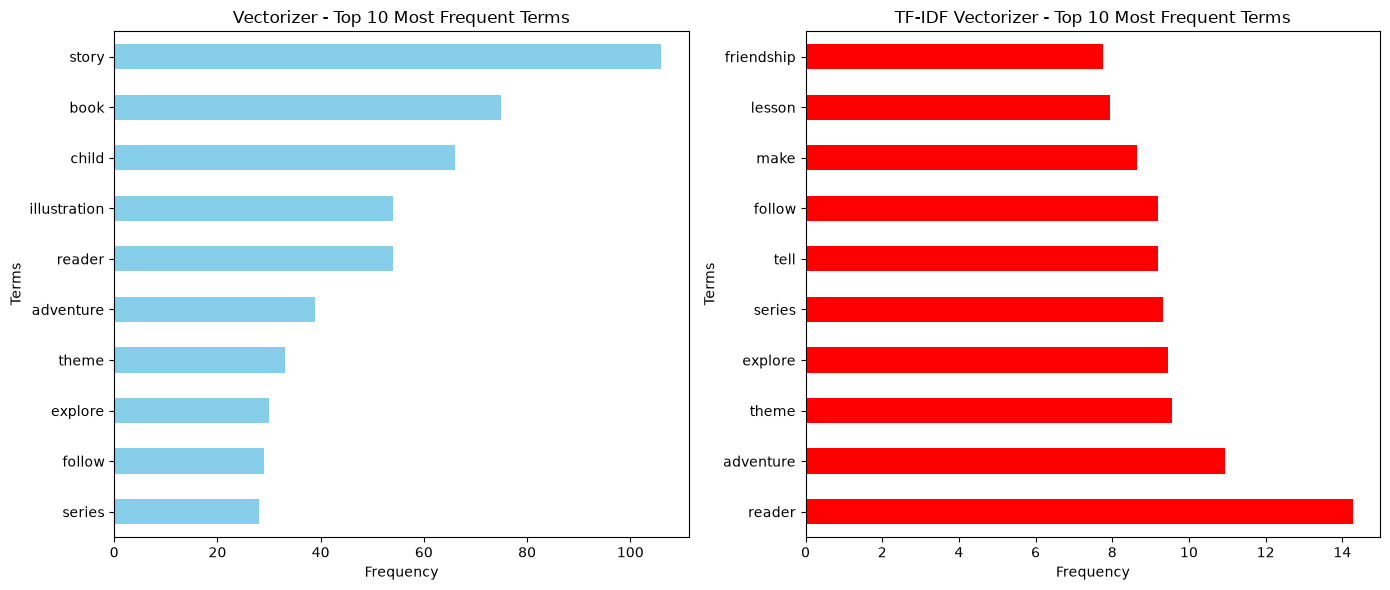

In [197]:
## Chart comparison of top 10 and least 10 most frequent terms
import matplotlib.pyplot as plt

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))

# Subplot 1: Vectorizer (Count Vectorizer)
top_10_dtm_freq.plot(
    kind='barh', 
    ax=axes[0], 
    title='Vectorizer - Top 10 Most Frequent Terms', 
    color='skyblue'
)
axes[0].set_xlabel('Frequency')
axes[0].set_ylabel('Terms')
axes[0].invert_yaxis()  # Displays the highest frequency term at the top

# Subplot 2: TF-IDF Vectorizer
top10.plot(
    kind='barh', 
    ax=axes[1], 
    title='TF-IDF Vectorizer - Top 10 Most Frequent Terms', 
    color='red'
)
axes[1].set_xlabel('Frequency')
axes[1].set_ylabel('Terms')
axes[1].invert_yaxis()  # Displays the highest frequency term at the top

plt.tight_layout()
plt.show()